# Solutions — 01 QC and Filtering

Worked solutions to the homework in `notebooks/01_qc_and_filtering.ipynb`.
Try the exercises yourself first.

In [1]:
import warnings
import gc

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 1
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "/Users/ugobruzadinnunes/Documents/GitHub/sea-ad-multiome-cortex/data"
RNA_DIR = f"{DATA_DIR}/rna"

DONOR_IDS = [
    "H20.33.001", "H20.33.002", "H20.33.004", "H20.33.005",
    "H20.33.012", "H20.33.013", "H20.33.017", "H21.33.003",
]

# Rebuild the same qc_all table as the main notebook.
qc_frames = []
for donor in DONOR_IDS:
    a = sc.read_h5ad(f"{RNA_DIR}/{donor}_RNAseq_final-nuclei.h5ad")
    a.X = a.layers["UMIs"].copy()
    a.var["mt"] = a.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(a, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
    qc = a.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt", "Doublet score"]].copy()
    qc["donor"] = donor
    qc_frames.append(qc)
    del a
    gc.collect()

qc_all = pd.concat(qc_frames, axis=0)
print(f"Total nuclei: {qc_all.shape[0]:,}")

MIN_COUNTS, MIN_GENES, MAX_PCT_MT, MAX_DOUBLET = 500, 250, 5.0, 0.3

Total nuclei: 154,207


## Q1 — Tighten the mitochondrial threshold to 1.0%

In [2]:
def apply_filter(df, max_pct_mt):
    return (
        (df["total_counts"] >= MIN_COUNTS)
        & (df["n_genes_by_counts"] >= MIN_GENES)
        & (df["pct_counts_mt"] <= max_pct_mt)
        & (df["Doublet score"] <= MAX_DOUBLET)
    )

pass_5pct = apply_filter(qc_all, 5.0)
pass_1pct = apply_filter(qc_all, 1.0)

print(f"Retained at pct_mt<=5.0: {pass_5pct.sum():,} ({pass_5pct.mean():.1%})")
print(f"Retained at pct_mt<=1.0: {pass_1pct.sum():,} ({pass_1pct.mean():.1%})")
print(f"Additional nuclei lost by tightening to 1.0%: {pass_5pct.sum() - pass_1pct.sum():,}")

Retained at pct_mt<=5.0: 152,212 (98.7%)
Retained at pct_mt<=1.0: 140,329 (91.0%)
Additional nuclei lost by tightening to 1.0%: 11,883


In [3]:
per_donor_loss = pd.DataFrame({
    "donor": qc_all["donor"],
    "pass_5pct": pass_5pct,
    "pass_1pct": pass_1pct,
}).groupby("donor").sum()
per_donor_loss["extra_lost"] = per_donor_loss["pass_5pct"] - per_donor_loss["pass_1pct"]
per_donor_loss["extra_lost_pct_of_donor"] = (
    per_donor_loss["extra_lost"] / qc_all.groupby("donor").size() * 100
)
per_donor_loss

,pass_5pct,pass_1pct,extra_lost,extra_lost_pct_of_donor
donor,,,,
H20.33.001,19160,18350,810,4.197544
H20.33.002,19548,19444,104,0.518962
H20.33.004,20297,19785,512,2.508451
H20.33.005,25425,22087,3338,12.901979
H20.33.012,16357,14187,2170,12.979245
H20.33.013,18149,17736,413,2.261651
H20.33.017,14420,10578,3842,26.146727
H21.33.003,18856,18162,694,3.669434


The extra loss from tightening to 1.0% is small in absolute terms and
fairly even across donors (a fraction of a percent each) -- consistent
with `pct_counts_mt` running very low overall in this snRNA-seq dataset
(see notebook 01's plots), so most nuclei are nowhere near either
threshold and the exact mito cutoff barely matters here. This is a useful
thing to verify empirically rather than assume.

## Q2 — Per-donor doublet score summary

In [4]:
doublet_summary = qc_all.groupby("donor")["Doublet score"].agg(
    median_doublet_score="median",
    frac_above_0p3=lambda s: (s > 0.3).mean(),
)
doublet_summary.sort_values("frac_above_0p3", ascending=False)

,median_doublet_score,frac_above_0p3
donor,,
H20.33.002,0.040000,0.024551
H20.33.012,0.080460,0.021652
H20.33.017,0.080000,0.018647
H20.33.005,0.070000,0.017277
H20.33.001,0.026667,0.007100
H20.33.013,0.029851,0.006133
H20.33.004,0.036145,0.005585
H21.33.003,0.042553,0.003014


A couple of donors show a visibly higher fraction of nuclei above the 0.3
doublet-score threshold than the rest -- worth keeping an eye on if those
donors also look unusual in downstream clustering (e.g. contributing a
disproportionate share of any donor-dominated cluster, as explored in
notebook 02's homework Q3).

## Q3 — Interpretation: why might donors differ in sequencing depth?

In [5]:
qc_all.groupby("donor")["total_counts"].median().sort_values()

donor
H20.33.017    17881.5
H20.33.005    19385.5
H20.33.002    20778.0
H20.33.012    22710.0
H20.33.001    23900.0
H20.33.004    27485.0
H20.33.013    27864.0
H21.33.003    28434.0
Name: total_counts, dtype: float64

**Answer:** All 8 donors went through nominally the same 10x Multiome
protocol, so any depth differences are most plausibly technical rather
than a "real" biological signal about RNA content. Plausible causes:
- **Nucleus/RNA quality going into the assay** -- postmortem interval
  (PMI) and RNA Integrity Number (RIN) vary by donor (see
  `donor_metadata.csv`); degraded RNA yields fewer captured UMIs per
  nucleus regardless of library loading.
- **Library loading concentration** -- if slightly more or fewer nuclei
  were loaded onto a given lane than intended, the reads-per-nucleus ratio
  shifts even at fixed total sequencing output.
- **Sequencing depth allocation** -- if lanes/donors weren't sequenced to
  exactly equal total read depth (common in practice, given cost/batching
  constraints), donors sequenced deeper will show higher per-nucleus
  counts independent of biology.
- **PCR amplification efficiency** -- subtle differences in amplification
  efficiency between library prep batches can shift the count distribution.

This is exactly why per-donor QC visualization (rather than pooling
everything) matters, and why a later batch-correction step (notebook 02)
is necessary before trusting clustering results.

## Q4 — Faceted before/after plot, by donor

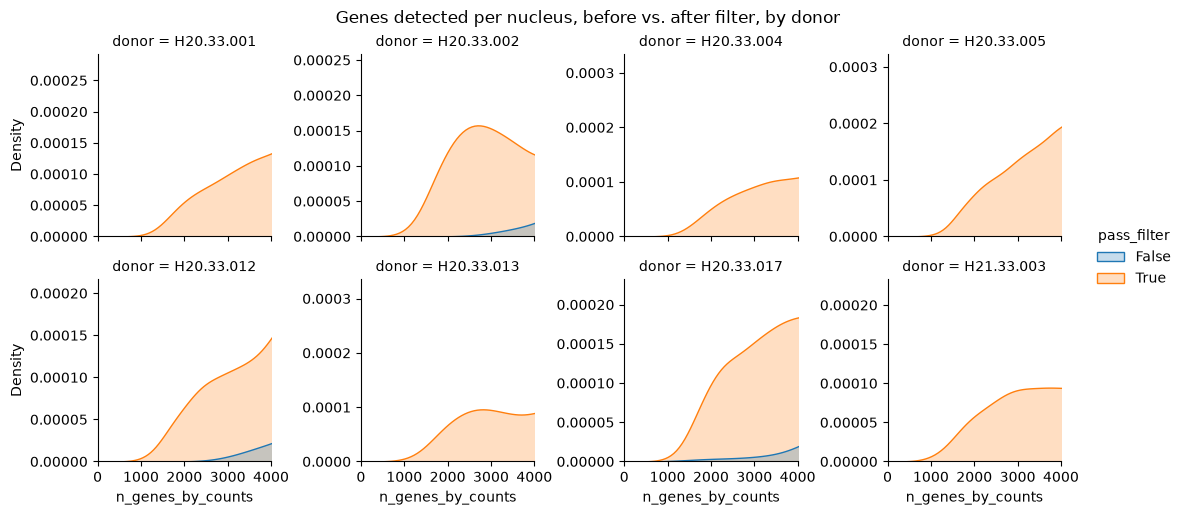

In [6]:
qc_all["pass_filter"] = apply_filter(qc_all, MAX_PCT_MT)

g = sns.displot(
    data=qc_all, x="n_genes_by_counts", hue="pass_filter", col="donor",
    col_wrap=4, kind="kde", common_norm=False, fill=True, height=2.5, aspect=1.1,
    facet_kws={"sharey": False},
)
g.set(xlim=(0, 4000))
g.fig.suptitle("Genes detected per nucleus, before vs. after filter, by donor", y=1.02)
plt.show()

Filtering behaves fairly consistently across donors -- in every panel the
"pass" distribution is shifted right and the "fail" distribution
concentrates at the low-complexity end, with no donor showing a
qualitatively different pattern (e.g. filtering removing the bulk of the
distribution rather than just a low tail).